In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import os, subprocess
import bioframe
from sample import *
from supp_lib import *
import seaborn as sns
import cooltools

In [2]:
# make matplotlib pdf-s text recognizable by evil-Adobe
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [3]:
cd /pi/robert.brown-umw/nl/ozgun/Snehal_HDD/cooltools54/EV1_flipped_versions_v2/EV1_flipped_Cis_Saddles

/pi/robert.brown-umw/nl/ozgun/Snehal_HDD/cooltools54/EV1_flipped_versions_v2/EV1_flipped_Cis_Saddles


/home/ozgun.uyan-umw/miniconda3/envs/cooltools054/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
info = pd.read_csv("../cooltools54/Sample_info.tsv",sep='\t')
info.head()

,Sample,PC,Color
0,OU-HiC-C2-pfib-D16,Patient,D16
1,OU-HiC-C2-pfib-D4,Patient,D4
2,OU-HiC-C3-pfib-D16,Patient,D16
3,OU-HiC-C3-pfib-D4,Patient,D4
4,OU-HiC-N6-pfib-D16,Control,D16


In [5]:
stn = pd.DataFrame(columns=['Sample','A','B'])
print(stn.head())
for i,f in enumerate(indi+grps):
    with np.load('/pi/robert.brown-umw/nl/ozgun/Snehal_HDD/cooltools54/EV1_flipped_versions_v2/EV1_flipped_Cis_Saddles/'+f+'.saddledump.npz') as data:
        x = data['saddle_strength-A']
        y = data['saddle_strength-B']
    A=np.around(x[int(np.floor(0.2*len(x)))],2)
    B=np.around(y[int(np.floor(0.2*len(y)))],2)
    stn.loc[i] = [f,A,B]

Empty DataFrame
Columns: [Sample, A, B]
Index: []


In [6]:
#stn = pd.read_csv("Strengths-cis-arms-1Mb.tsv",sep='\t')
stn.head()

,Sample,A,B
0,OU-HiC-C2-pfib-D16,3.98,6.93
1,OU-HiC-C2-pfib-D4,5.22,9.08
2,OU-HiC-C3-pfib-D16,4.48,7.58
3,OU-HiC-C3-pfib-D4,5.62,9.09
4,OU-HiC-N6-pfib-D16,3.61,6.39


In [7]:
fin = pd.merge(stn,info,on='Sample')
fin.head()
#save in case , want to change PC/Color columns manually
fin.to_csv("/pi/robert.brown-umw/nl/ozgun/Snehal_HDD/cooltools54/EV1_flipped_versions_v2/EV1_flipped_Cis_Saddles/cis_groups/Strengths-cis-arms.tsv",sep='\t',index=False)






In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# ── User parameters ────────────────────────────────────────────────────────────
file_path = "/pi/robert.brown-umw/nl/ozgun/Snehal_HDD/cooltools54/EV1_flipped_versions_v2/EV1_flipped_Cis_Saddles/cis_groups/Strengths-cis-arms.tsv"

# groups to plot
data_list = ["N6", "C3", "C3", "C3"]

# the six sample‐type labels you want (must match what's in your file)
name_list = ["pfib-D16","pfib-D4","IPSC1","MN-1","IPSC3","MN-2"]

# the colors you want for each of those six
colors = ['#FD8008','#FB0207','#FC6666','#0000FF','#FC6666','#0000FF']
# ────────────────────────────────────────────────────────────────────────────────

# 1) Load data
df = pd.read_csv(file_path, sep='\t')

# 2) Extract the 4‐letter group code (N6, C3, C3, C3)
df['Group'] = df['Sample'].str.extract(r'OU-HiC-(N6|C3|C3|C3)')

# 3) Chop off the prefix so we can pull out your "sample type"
#    (pfib-D16, pfib-D4, IPSC1, MN-1, IPSC3, MN-2, etc.)
df['suffix'] = df['Sample'].str.replace(r'^OU-HiC-(?:N6|C3|C3|C3)-', '',
                                        regex=True)

def get_type(s):
    if s.startswith('pfib'):
        return s            # keeps "pfib-D16" or "pfib-D4"
    if s.startswith('MN-'):
        return s            # keeps "MN-1" or "MN-2"
    return s.split('-')[0]  # turns "IPSC1-R1" → "IPSC1", "IPSC3-R1" → "IPSC3"

df['Type'] = df['suffix'].apply(get_type)

# 4) Keep only the 6 types you listed
df = df[df['Type'].isin(name_list)]

# 5) Setup 4×1 panels
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(6, 16), sharex=False)

# find global axis limits (optional)
xmin, xmax = 1, df['A'].max() + 1
ymin, ymax = 1, df['B'].max() + 1

# 6) Loop over each group
for ax, grp in zip(axes, data_list):
    sub = df[df['Group'] == grp]
    
    # plot each sample type with your colors
    for typ, col in zip(name_list, colors):
        dat = sub[sub['Type'] == typ]
        ax.scatter(dat['A'], dat['B'], color=col, s=80, label=typ)
    
    # formatting
    ax.set_title(f"Group {grp}", fontsize=12)
    ax.set_xlabel("A", fontsize=10)
    ax.set_ylabel("B", fontsize=10)
    ax.set_xlim(xmin, 10)
    ax.set_ylim(ymin, 10)
    ax.set_aspect('equal', 'box')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(title="Sample Type", bbox_to_anchor=(1.02, 1),
              loc='upper left', fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 38 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'I', 'M', 'N', 'P', 'S', 'W', 'a', 'b', 'c', 'e', 'eight', 'f', 'four', 'hyphen', 'i', 'l', 'm', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 's', 'six', 'space', 't', 'three', 'two', 'u', 'underscore', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 16, 19, 20, 21, 22, 23, 25, 27, 36, 37, 38, 39, 40, 44, 48, 49, 51, 54, 58, 66, 68, 69, 70, 72, 73, 76, 79, 80, 82, 83, 85, 86, 87, 88]
INFO:fontTools.subset:Closed glyph list over 'GSUB': 43 glyphs after
INFO:fontTools

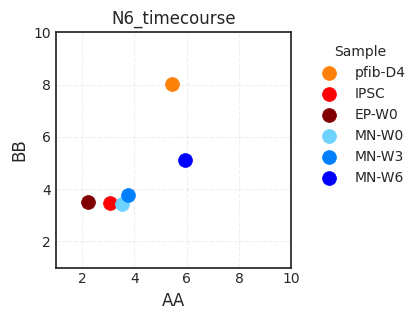

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load your TSV
df = pd.read_csv("/pi/robert.brown-umw/nl/ozgun/Snehal_HDD/cooltools54/EV1_flipped_versions_v2/EV1_flipped_Cis_Saddles/cis_groups/Strengths-cis-arms.tsv", sep='\t')

# 2) Define exactly the 6 samples you want to plot, with suffix keys, full names, and colors
full_names = {
    "pfib-D4":      "OU-HiC-N6-pfib-D4",
    "IPSC":         "OU-HiC-N6IPSC2-R1",
    "EP-W0":        "OU-HiC-N6IPSC2-EP-W0",
    "MN-W0":        "OU-HiC-N6IPSC2-MN-W0",
    "MN-W3":         "OU-HiC-N6IPSC2-MN-W3",
    "MN-W6":         "OU-HiC-N6IPSC2-MN-W6",
}
sample_colors = {
    "pfib-D4":   "#FD8008",
    "IPSC":      "#FB0207",
    "EP-W0":     "#800002",
    "MN-W0":     "#6ED2FF",
    "MN-W3":     "#0080FF",
    "MN-W6":     "#0000FF",
}

legend_labels = {
    "pfib-D4":   "pfib-D4",
    "IPSC":      "IPSC",
    "EP-W0":     "EP-W0",
    "MN-W0":     "MN-W0",
    "MN-W3":     "MN-W3",
    "MN-W6":     "MN-W6",
}

#FD8008','#FB0207','#FC6666','#0000FF','#FC6666','#0000FF'
# 3) Prepare the figure (square)
fig, ax = plt.subplots(figsize=(5,3.3))

# 4) Plot each sample
for suf, full in full_names.items():
    sub = df[df["Sample"] == full]
    if sub.empty:
        continue
    ax.scatter(
        sub["A"], sub["B"],
        s=100,
        color=sample_colors[suf],
        marker='o',          # big cross marker
        label=legend_labels.get(suf, suf),
        #edgecolor='k',       # black edge for visibility
        linewidth=0.5
    )

# 5) Set axis limits starting at 1
xmin, xmax = 1, df["A"].max() + 1
ymin, ymax = 1, df["B"].max() + 1
ax.set_xlim(xmin, 10)
ax.set_ylim(ymin, 10)

# 6) Force a square aspect ratio
ax.set_aspect('equal', 'box')

# 7) Labels, grid, legend
ax.set_xlabel("AA", fontsize=12)
ax.set_ylabel("BB", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(
    title="Sample",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.5
)

plt.title("N6_timecourse")
plt.tight_layout()
plt.savefig("/pi/robert.brown-umw/nl/ozgun/Snehal_HDD/cooltools54/EV1_flipped_versions_v2/N6_comp_str_cis_timecourse.pdf")
plt.show()


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 39 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'I', 'M', 'N', 'P', 'S', 'W', 'a', 'b', 'c', 'e', 'eight', 'f', 'four', 'hyphen', 'i', 'l', 'm', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 's', 'six', 'space', 't', 'three', 'two', 'u', 'underscore', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 16, 19, 20, 21, 22, 23, 25, 27, 28, 36, 37, 38, 39, 40, 44, 48, 49, 51, 54, 58, 66, 68, 69, 70, 72, 73, 76, 79, 80, 82, 83, 85, 86, 87, 88]
INFO:fontTools.subset:Closed glyph list over 'GSUB': 44 glyphs after
IN

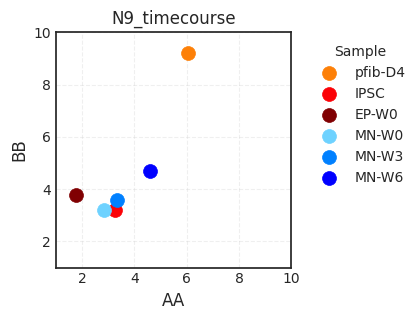

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load your TSV
df = pd.read_csv("/pi/robert.brown-umw/nl/ozgun/Snehal_HDD/cooltools54/EV1_flipped_versions_v2/EV1_flipped_Cis_Saddles/cis_groups/Strengths-cis-arms.tsv", sep='\t')

# 2) Define exactly the 6 samples you want to plot, with suffix keys, full names, and colors
full_names = {
    "pfib-D4":      "OU-HiC-N9-pfib-D4",
    "IPSC":         "OU-HiC-N9IPSC2-R1",
    "EP-W0":        "OU-HiC-N9IPSC2-EP-W0",
    "MN-W0":        "OU-HiC-N9IPSC2-MN-W0",
    "MN-W3":        "OU-HiC-N9IPSC2-MN-W3",
    "MN-W6":        "OU-HiC-N9IPSC2-MN-W6",
}
sample_colors = {
    "pfib-D4":   "#FD8008",
    "IPSC":      "#FB0207",
    "EP-W0":     "#800002",
    "MN-W0":     "#6ED2FF",
    "MN-W3":     "#0080FF",
    "MN-W6":     "#0000FF",
}

legend_labels = {
    "pfib-D4":   "pfib-D4",
    "IPSC":      "IPSC",
    "EP-W0":     "EP-W0",
    "MN-W0":     "MN-W0",
    "MN-W3":     "MN-W3",
    "MN-W6":     "MN-W6",
}

#FD8008','#FB0207','#FC6666','#0000FF','#FC6666','#0000FF'
# 3) Prepare the figure (square)
fig, ax = plt.subplots(figsize=(5,3.3))

# 4) Plot each sample
for suf, full in full_names.items():
    sub = df[df["Sample"] == full]
    if sub.empty:
        continue
    ax.scatter(
        sub["A"], sub["B"],
        s=100,
        color=sample_colors[suf],
        marker='o',          # big cross marker
        label=legend_labels.get(suf, suf),
        #edgecolor='k',       # black edge for visibility
        linewidth=0.5
    )

# 5) Set axis limits starting at 1
xmin, xmax = 1, df["A"].max() + 1
ymin, ymax = 1, df["B"].max() + 1
ax.set_xlim(xmin, 10)
ax.set_ylim(ymin, 10)

# 6) Force a square aspect ratio
ax.set_aspect('equal', 'box')

# 7) Labels, grid, legend
ax.set_xlabel("AA", fontsize=12)
ax.set_ylabel("BB", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(
    title="Sample",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.5
)

plt.title("N9_timecourse")
plt.tight_layout()
plt.savefig("/pi/robert.brown-umw/nl/ozgun/Snehal_HDD/cooltools54/EV1_flipped_versions_v2/N9_comp_str_cis_timecourse.pdf")
plt.show()


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 39 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'I', 'M', 'N', 'P', 'S', 'W', 'a', 'b', 'c', 'e', 'eight', 'f', 'four', 'hyphen', 'i', 'l', 'm', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 's', 'six', 'space', 't', 'three', 'two', 'u', 'underscore', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 16, 19, 20, 21, 22, 23, 25, 27, 28, 36, 37, 38, 39, 40, 44, 48, 49, 51, 54, 58, 66, 68, 69, 70, 72, 73, 76, 79, 80, 82, 83, 85, 86, 87, 88]
INFO:fontTools.subset:Closed glyph list over 'GSUB': 44 glyphs after
IN

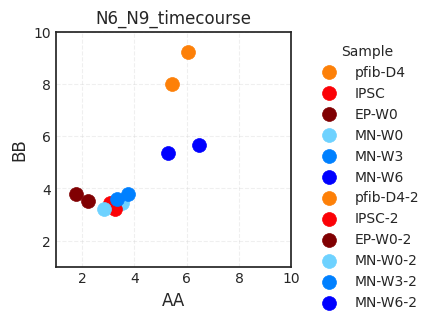

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load your TSV
df = pd.read_csv("/pi/robert.brown-umw/nl/ozgun/Snehal_HDD/cooltools54/EV1_flipped_versions_v2/EV1_flipped_Cis_Saddles/cis_groups/Strengths-cis-arms.tsv", sep='\t')

# 2) Define exactly the 6 samples you want to plot, with suffix keys, full names, and colors
full_names = {
    "pfib-D4":      "OU-HiC-N6-pfib-D4",
    "IPSC":         "OU-HiC-N6IPSC2-R1",
    "EP-W0":        "OU-HiC-N6IPSC2-EP-W0",
    "MN-W0":        "OU-HiC-N6IPSC2-MN-W0",
    "MN-W3":         "OU-HiC-N6IPSC2-MN-W3",
    "MN-W6":         "OU-HiC-N6IPSC2MND45-R2",
    "pfib-D4-2":      "OU-HiC-N9-pfib-D4",
    "IPSC-2":         "OU-HiC-N9IPSC2-R1",
    "EP-W0-2":        "OU-HiC-N9IPSC2-EP-W0",
    "MN-W0-2":        "OU-HiC-N9IPSC2-MN-W0",
    "MN-W3-2":        "OU-HiC-N9IPSC2-MN-W3",
    "MN-W6-2":        "OU-HiC-N9IPSC2MND45-R2",
}
sample_colors = {
    "pfib-D4":   "#FD8008",
    "IPSC":      "#FB0207",
    "EP-W0":     "#800002",
    "MN-W0":     "#6ED2FF",
    "MN-W3":     "#0080FF",
    "MN-W6":     "#0000FF",
    "pfib-D4-2":   "#FD8008",
    "IPSC-2":      "#FB0207",
    "EP-W0-2":     "#800002",
    "MN-W0-2":     "#6ED2FF",
    "MN-W3-2":     "#0080FF",
    "MN-W6-2":     "#0000FF",
}

legend_labels = {
    "pfib-D4":   "pfib-D4",
    "IPSC":      "IPSC",
    "EP-W0":     "EP-W0",
    "MN-W0":     "MN-W0",
    "MN-W3":     "MN-W3",
    "MN-W6":     "MN-W6",
}

#FD8008','#FB0207','#FC6666','#0000FF','#FC6666','#0000FF'
# 3) Prepare the figure (square)
fig, ax = plt.subplots(figsize=(5,3.3))

# 4) Plot each sample
for suf, full in full_names.items():
    sub = df[df["Sample"] == full]
    if sub.empty:
        continue
    ax.scatter(
        sub["A"], sub["B"],
        s=100,
        color=sample_colors[suf],
        marker='o',          # big cross marker
        label=legend_labels.get(suf, suf),
        #edgecolor='k',       # black edge for visibility
        linewidth=0.5
    )

# 5) Set axis limits starting at 1
xmin, xmax = 1, df["A"].max() + 1
ymin, ymax = 1, df["B"].max() + 1
ax.set_xlim(xmin, 10)
ax.set_ylim(ymin, 10)

# 6) Force a square aspect ratio
ax.set_aspect('equal', 'box')

# 7) Labels, grid, legend
ax.set_xlabel("AA", fontsize=12)
ax.set_ylabel("BB", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(
    title="Sample",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.5
)

plt.title("N6_N9_timecourse")
plt.tight_layout()
plt.savefig("/pi/robert.brown-umw/nl/ozgun/Snehal_HDD/cooltools54/EV1_flipped_versions_v2/N6_N9_combined_comp_str_cis_timecourse_v2.pdf")
plt.show()


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 29 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'I', 'M', 'N', 'P', 'S', 'a', 'b', 'e', 'eight', 'f', 'four', 'hyphen', 'i', 'l', 'm', 'nonmarkingreturn', 'one', 'p', 'six', 'space', 'three', 'two', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 16, 19, 20, 21, 22, 23, 25, 27, 36, 37, 38, 39, 44, 48, 49, 51, 54, 68, 69, 72, 73, 76, 79, 80, 83]
INFO:fontTools.subset:Closed glyph list over 'GSUB': 34 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'I', 'M', 'N', 'P', 'S', 'a'

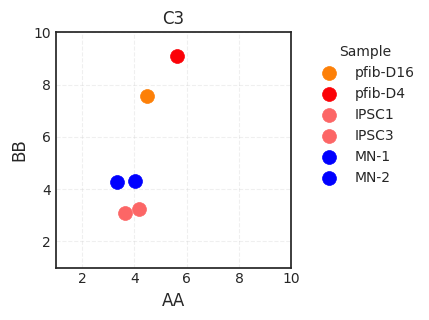

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load your TSV
df = pd.read_csv("/pi/robert.brown-umw/nl/ozgun/Snehal_HDD/cooltools54/EV1_flipped_versions_v2/EV1_flipped_Cis_Saddles/cis_groups/Strengths-cis-arms.tsv", sep='\t')

# 2) Define exactly the 6 samples you want to plot, with suffix keys, full names, and colors
full_names = {
    "pfib-D16":      "OU-HiC-C3-pfib-D16",
    "pfib-D4":       "OU-HiC-C3-pfib-D4",
    "IPSC1":         "OU-HiC-C3IPSC3-R2",
    "IPSC3":         "OU-HiC-C3IPSC4-R1",
    "MN-1":          "OU-HiC-C3IPSC3MND45-R1",
    "MN-2":          "OU-HiC-C3IPSC4MND45-R1",
}
sample_colors = {
    "pfib-D16": "#FD8008",
    "pfib-D4":  "#FB0207",
    "IPSC1":    "#FC6666",
    "IPSC3":    "#FC6666",
    "MN-1":     "#0000FF",
    "MN-2":     "#0000FF",
}

legend_labels = {
    "pfib-D16": "pfib-D16",
    "pfib-D4":  "pfib-D4",
    "IPSC1":    "IPSC1",
    "IPSC3":    "IPSC3",
    "MN-1":     "MN-1",
    "MN-2":     "MN-2",
}

#FD8008','#FB0207','#FC6666','#0000FF','#FC6666','#0000FF'
# 3) Prepare the figure (square)
fig, ax = plt.subplots(figsize=(5,3.3))

# 4) Plot each sample
for suf, full in full_names.items():
    sub = df[df["Sample"] == full]
    if sub.empty:
        continue
    ax.scatter(
        sub["A"], sub["B"],
        s=100,
        color=sample_colors[suf],
        marker='o',          # big cross marker
        label=legend_labels.get(suf, suf),
        #edgecolor='k',       # black edge for visibility
        linewidth=0.5
    )

# 5) Set axis limits starting at 1
xmin, xmax = 1, df["A"].max() + 1
ymin, ymax = 1, df["B"].max() + 1
ax.set_xlim(xmin, 10)
ax.set_ylim(ymin, 10)

# 6) Force a square aspect ratio
ax.set_aspect('equal', 'box')

# 7) Labels, grid, legend
ax.set_xlabel("AA", fontsize=12)
ax.set_ylabel("BB", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(
    title="Sample",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.5
)

plt.title("C3")
plt.tight_layout()
plt.savefig("/pi/robert.brown-umw/nl/ozgun/Snehal_HDD/cooltools54/EV1_flipped_versions_v2/C3_comp_str_cis_Fib-IPSC3-MN.pdf")
plt.show()


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 43 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'I', 'M', 'N', 'P', 'S', 'T', 'W', 'a', 'b', 'colon', 'e', 'eight', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 16, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 36, 37, 38, 39, 40, 41, 44, 48, 49, 51, 54, 55, 58, 68, 69, 72, 74, 75, 76, 79, 80, 81, 82, 83, 85, 86, 87]
INFO:fontTools.subset:Closed glyp

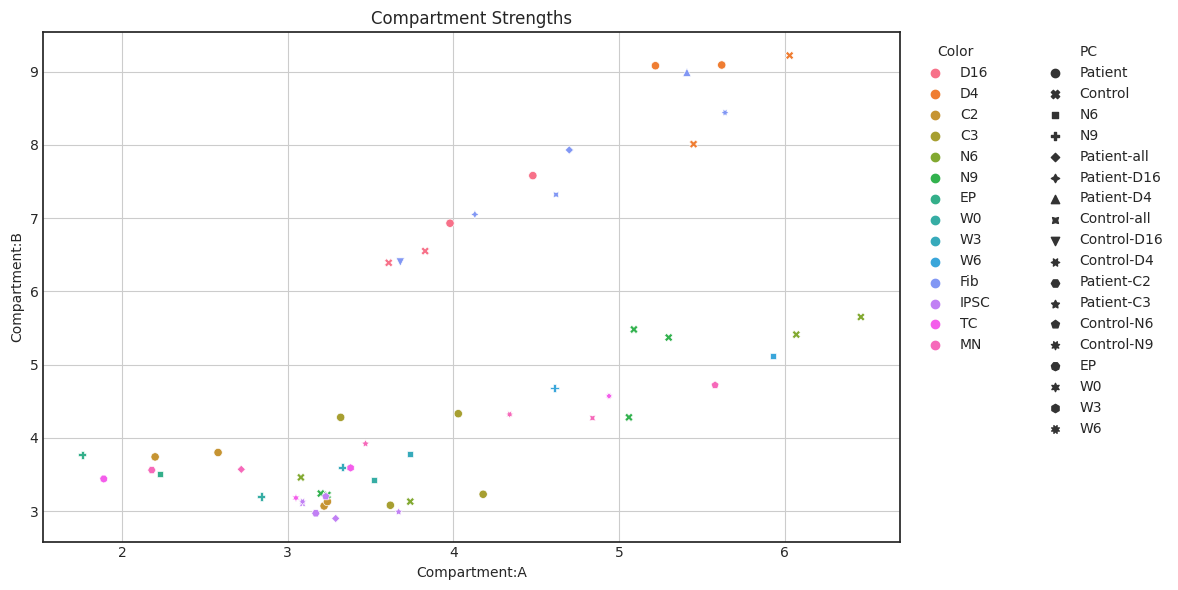

In [12]:
fig = plt.figure(figsize=(12, 6))
ax = plt.gca()
sns.scatterplot(data=fin, x="A", y="B",style='PC',hue='Color')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
#plt.xlim(1.4, 3)
#plt.ylim(1.4, 2.2)

# Get handles and labels for hue and style
hue_handles, hue_labels = ax.get_legend_handles_labels()

# Separate hue and style
# Assumes order: hue entries first, then style
# Adjust slicing if needed
num_colors = fin['Color'].nunique()
num_styles = fin['PC'].nunique()

color_handles = hue_handles[1:1+num_colors]
color_labels = hue_labels[1:1+num_colors]

pc_handles = hue_handles[1+num_colors:]
pc_labels = hue_labels[1+num_colors:]

# Remove default legend
ax.legend_.remove()

# Create two separate legends
legend1 = ax.legend(color_handles, color_labels, title="Color", loc='upper left', bbox_to_anchor=(1.01, 1))
legend2 = ax.legend(pc_handles, pc_labels, loc='upper left', bbox_to_anchor=(1.15, 1))

# Add both legends to the axes
ax.add_artist(legend1)


plt.grid()
plt.xlabel("Compartment:A")
plt.ylabel("Compartment:B")
plt.title("Compartment Strengths")
plt.tight_layout()
#plt.savefig("GitHub/Plots/Strength.pdf",bbox_inches='tight')